In [122]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd
import muon as mu
import anndata as ad
import nichepca as npc
import scipy.sparse as sparse

import os
import sys
from pathlib import Path

# Add the src directory to the path if it's not already there
notebook_dir = Path(os.getcwd())
if notebook_dir.name == 'src':
    sys.path.append(".")  # Add current directory
else:
    sys.path.append(str(notebook_dir / "src"))  # Add src directory

from config import H5AD_DIR, get_h5ad_path

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [123]:
ad_sp = sc.read_h5ad(get_h5ad_path("c_sp_ad.h5ad"))

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/scanpy/plotting/_utils.py:715: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


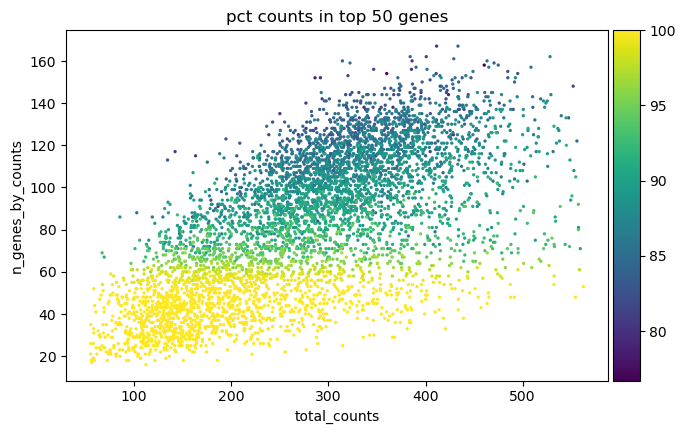

In [124]:
sc.pl.scatter(ad_sp, "total_counts", "n_genes_by_counts", color="pct_counts_in_top_50_genes")

/nfs/home/students/l.reich/mamba/envs/neu/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


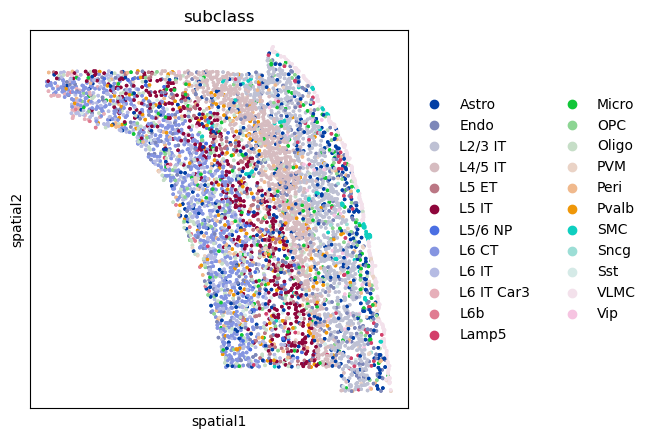

In [129]:
sq.pl.spatial_scatter(
    ad_sp, shape=None, color="subclass", size=10
)

In [95]:
sq.gr.spatial_neighbors(ad_sp, coord_type="generic")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1418.19/s]


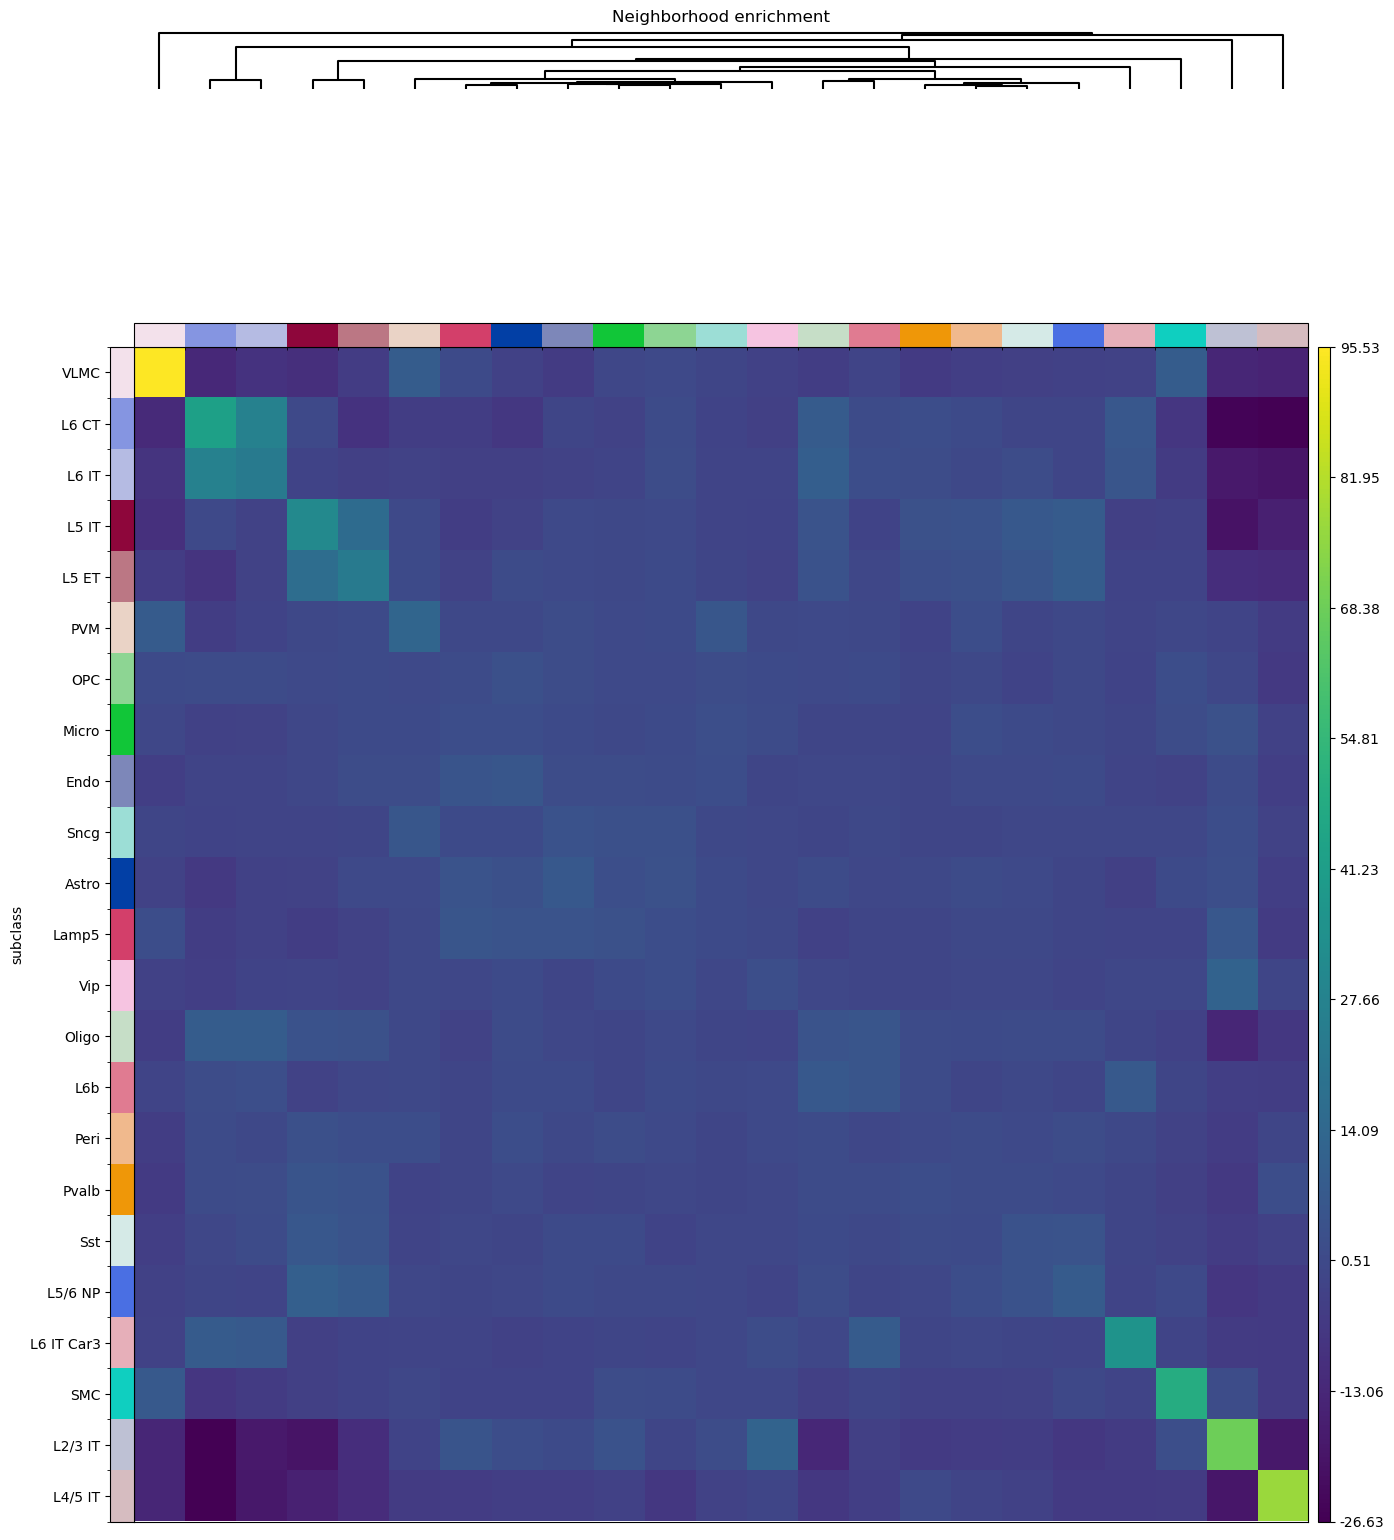

In [96]:
sq.gr.nhood_enrichment(ad_sp, cluster_key="subclass")
sq.pl.nhood_enrichment(ad_sp, cluster_key="subclass", method="ward")

In [97]:
sq.gr.spatial_autocorr(ad_sp, mode="geary")

maybe obere linie muss weg siehe die ersten 2

In [98]:
geary_gene_names_list = ad_sp.uns["gearyC"].head(n=20).index.tolist()
print(geary_gene_names_list)

['Rorb', 'Igf2', 'Gfap', 'Rspo1', 'Cux2', 'Lamp5', 'Calb1', 'Unc5d', 'Fam19a2', 'Slc17a6', 'Otof', 'Serpinf1', 'Nr4a2', 'Sulf1', 'Prr16', 'Tac2', 'Camk2d', 'Bcl11b', 'Cdh9', 'Cdh12']


In [99]:
sq.gr.spatial_autocorr(ad_sp, mode="moran")

In [100]:
moran_gene_names_list = ad_sp.uns["moranI"].head(n=20).index.tolist()
print(moran_gene_names_list)

['Gfap', 'Rorb', 'Igf2', 'Rspo1', 'Cux2', 'Lamp5', 'Unc5d', 'Calb1', 'Fam19a2', 'Slc17a6', 'Serpinf1', 'Otof', 'Sulf1', 'Acta2', 'Prr16', 'Tac2', 'Camk2d', 'Cdh9', 'Cdh12', 'Bcl11b']


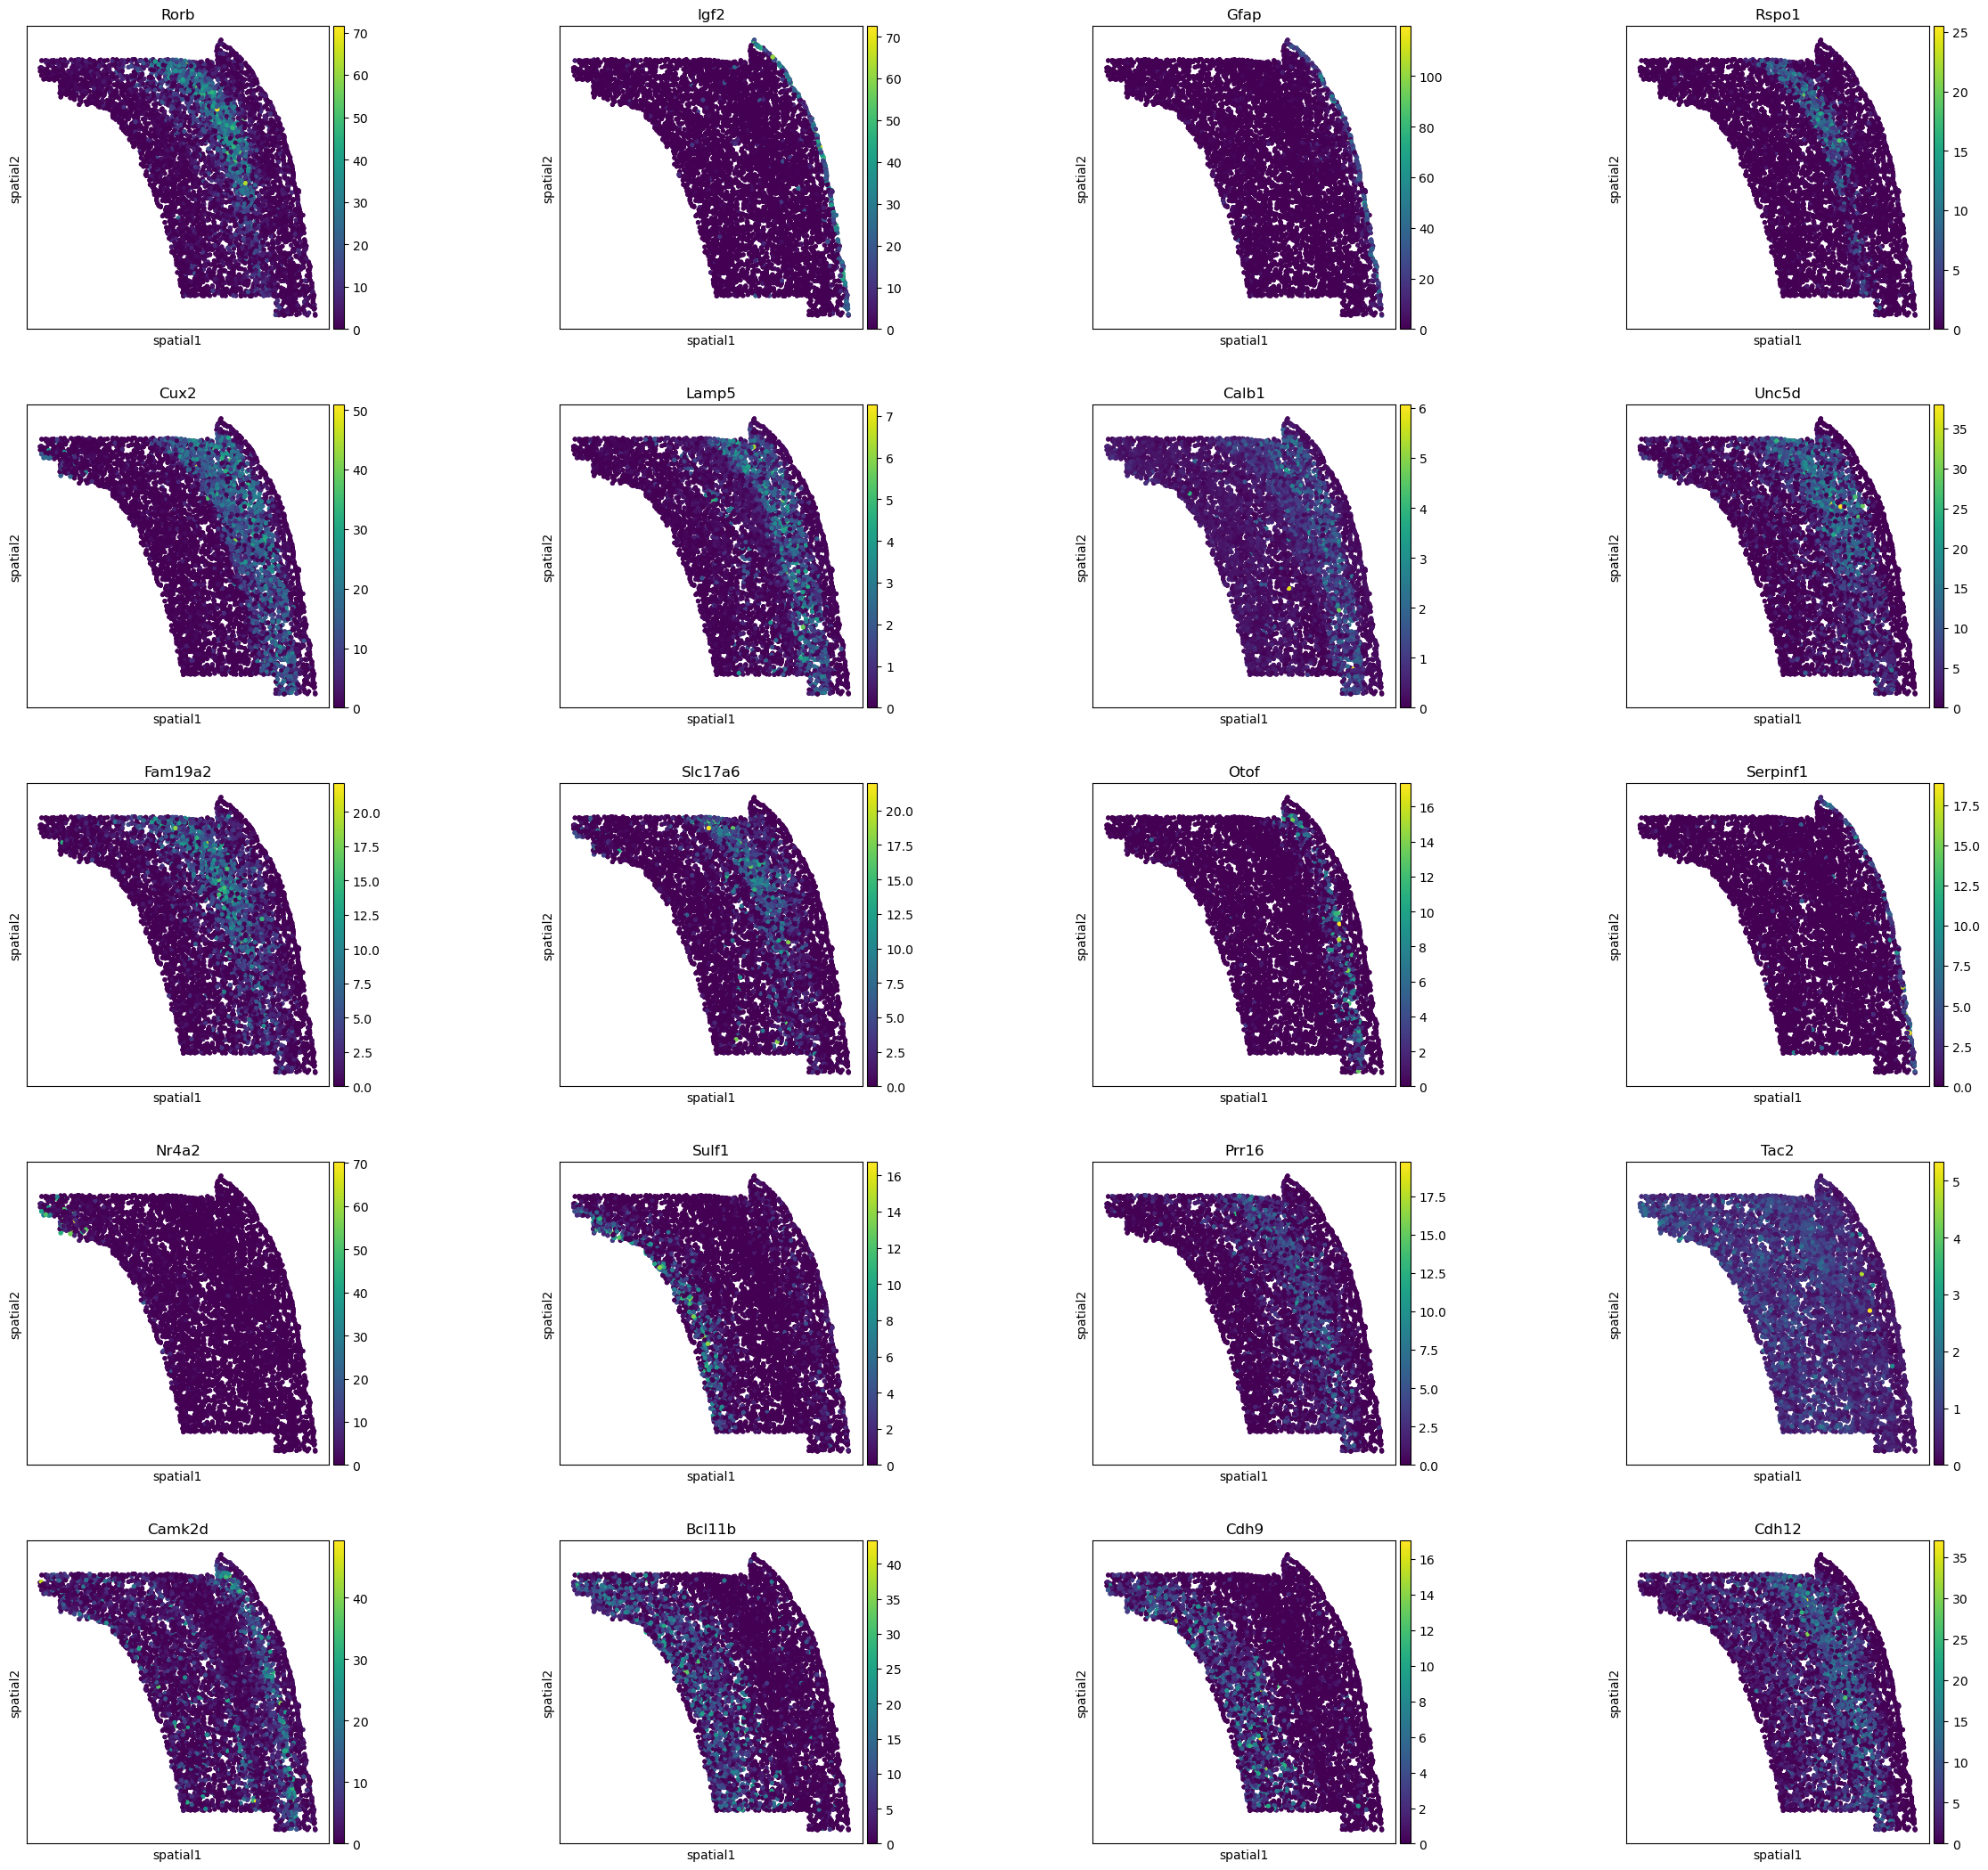

In [101]:
sq.pl.spatial_scatter(
    ad_sp, shape=None, color=geary_gene_names_list, size=30
)

In [102]:
# Convert the lists to sets
moran_genes_set = set(moran_gene_names_list)
geary_genes_set = set(geary_gene_names_list)

# Find the intersection using the intersection() method or the & operator
overlapping_genes = moran_genes_set.intersection(geary_genes_set)
# Or using the & operator:
# overlapping_genes = moran_genes_set & geary_genes_set

# Get the number of overlapping genes
num_overlapping_genes = len(overlapping_genes)

print(f"Number of genes overlapping in the top 20 for both measures: {num_overlapping_genes}")
print(f"Overlapping genes: {overlapping_genes}")

Number of genes overlapping in the top 20 for both measures: 19
Overlapping genes: {'Bcl11b', 'Unc5d', 'Rorb', 'Igf2', 'Otof', 'Gfap', 'Serpinf1', 'Cux2', 'Rspo1', 'Cdh12', 'Lamp5', 'Calb1', 'Slc17a6', 'Fam19a2', 'Cdh9', 'Camk2d', 'Sulf1', 'Tac2', 'Prr16'}


In [103]:
# Genes in top 20 Moran that are NOT in top 20 Geary
unique_to_moran = moran_genes_set - geary_genes_set

# Genes in top 20 Geary that are NOT in top 20 Moran
unique_to_geary = geary_genes_set - moran_genes_set

print(f"Genes in top 20 Moran only: {unique_to_moran}")
print(f"Genes in top 20 Geary only: {unique_to_geary}")

Genes in top 20 Moran only: {'Acta2'}
Genes in top 20 Geary only: {'Nr4a2'}


In [104]:
ad_sp.uns["gearyC"]

,C,pval_norm,var_norm,pval_norm_fdr_bh
Rorb,0.430073,0.000000e+00,0.000058,0.000000e+00
Igf2,0.432490,0.000000e+00,0.000058,0.000000e+00
Gfap,0.435107,0.000000e+00,0.000058,0.000000e+00
Rspo1,0.459914,0.000000e+00,0.000058,0.000000e+00
Cux2,0.471580,0.000000e+00,0.000058,0.000000e+00
...,...,...,...,...
Col15a1,1.030872,2.601505e-05,0.000058,3.797599e-05
Th,1.031675,1.651002e-05,0.000058,2.438107e-05
Ndst4,1.034804,2.538871e-06,0.000058,3.908323e-06
Prok2,1.036184,1.055478e-06,0.000058,1.644732e-06
